Using device: cpu
Epoch 1/5 | Average Loss: 0.3359
Epoch 2/5 | Average Loss: 0.1381
Epoch 3/5 | Average Loss: 0.0950
Epoch 4/5 | Average Loss: 0.0726
Epoch 5/5 | Average Loss: 0.0569
Accuracy: 97.47%
Model saved as digit_model.pth


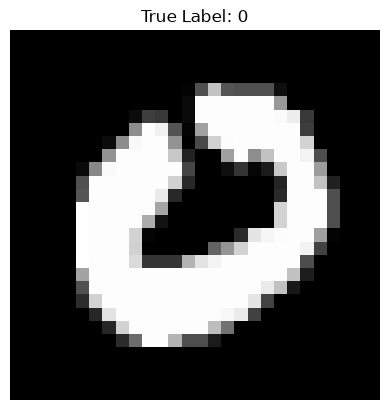

User picked image index: 25
True label: 0
Predicted label: 0


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.ToTensor()
train_data = MNIST(root='./data', train=True, download=True, transform=transform)   
test_data = MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

model = DigitModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # FIX: Moved print statement outside the batch loop and averaged the loss
    print(f"Epoch {epoch+1}/{epochs} | Average Loss: {total_loss / len(train_loader):.4f}")

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        prediction = outputs.argmax(dim=1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)

print(f"Accuracy: {100 * correct / total:.2f}%")

torch.save(model.state_dict(), "digit_model.pth")
print("Model saved as digit_model.pth")

index = 25
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("User picked image index:", index)
print("True label:", true_label)
print("Predicted label:", predicted_label)